# Merged Dataset Classification — Baseline CNN

**Datasets:** Dataset 1 (118 subjects) · UCI HAR (30 subjects) · WISDM (51 subjects)  
**Total:** 199 subjects · window = 128 · 6 channels (acc + gyro)  
**Model:** Plain `GaitCNN` trained end-to-end — no LoRA, no CDML, no frozen backbone  
**Split:** stratified 70 / 15 / 15 (train / val / test)

| Dataset   | Subjects | Window        | Global labels |
|-----------|----------|---------------|---------------|
| Dataset 1 | 118      | 128           | 0 – 117       |
| UCI HAR   | 30       | 128           | 118 – 147     |
| WISDM     | 51       | 200 → **128** | 148 – 198     |

WISDM windows are **centre-cropped** from 200 → 128 samples so all inputs  
share the same shape. Normalisation is computed per-dataset from the  
training fold only and then applied to val/test.

## 0. Imports

In [43]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

DEVICE = torch.device('mps')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : mps
PyTorch: 2.8.0


## 1. Configuration

In [44]:
# ── Paths ─────────────────────────────────────────────────────────────────────
D1_TRAIN_DIR = '../Data/Dataset_1/train'
D1_TEST_DIR  = '../Data/Dataset_1/test'
UCI_DATA_DIR = '../Data/UCI HAR Dataset'
WSD_DATA_DIR = '../Data/wisdm-dataset'

# ── Sensor / window ───────────────────────────────────────────────────────────
N_CHANNELS      = 6
D1_WINDOW_SIZE  = 128
WSD_WINDOW_SIZE = 200          # WISDM native; centre-cropped to 128 below
WINDOW_SIZE     = 128          # unified input size

# ── Model ─────────────────────────────────────────────────────────────────────
EMBED_DIM     = 128
ADAPTIVE_SIZE = 8              # AdaptiveAvgPool1d output; flat = 128 × 8 = 1024

# ── Dataset sizes ─────────────────────────────────────────────────────────────
D1_N_CLASSES  = 118
UCI_N_CLASSES = 30
WSD_N_CLASSES = 51
N_CLASSES     = D1_N_CLASSES + UCI_N_CLASSES + WSD_N_CLASSES   # 199

# Global label offsets
D1_OFFSET  = 0
UCI_OFFSET = D1_N_CLASSES                        # 118
WSD_OFFSET = D1_N_CLASSES + UCI_N_CLASSES        # 148

# ── Training ──────────────────────────────────────────────────────────────────
RANDOM_SEED  = 27
BATCH_SIZE   = 128
EPOCHS       = 100
LR_INIT      = 1e-3
LR_DECAY     = 0.98

TRAIN_FRAC   = 0.70
VAL_FRAC     = 0.15
TEST_FRAC    = 0.15

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Total subjects : {N_CLASSES}')
print(f'  Dataset 1  : {D1_N_CLASSES}  → labels {D1_OFFSET:>3} – {UCI_OFFSET - 1}')
print(f'  UCI HAR    : {UCI_N_CLASSES}  → labels {UCI_OFFSET:>3} – {WSD_OFFSET - 1}')
print(f'  WISDM      : {WSD_N_CLASSES} → labels {WSD_OFFSET:>3} – {N_CLASSES - 1}')


Total subjects : 199
  Dataset 1  : 118  → labels   0 – 117
  UCI HAR    : 30  → labels 118 – 147
  WISDM      : 51 → labels 148 – 198


## 2. Model — GaitCNN

In [45]:
class ConvBlock(nn.Module):
    """Conv1d → BatchNorm → ReLU → MaxPool1d."""
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """
    4-layer 1-D CNN for subject identification.
    AdaptiveAvgPool1d makes the flat dimension independent of window length.
    """
    def __init__(self, n_channels=N_CHANNELS, n_classes=N_CLASSES,
                 embed_dim=EMBED_DIM, adaptive_size=ADAPTIVE_SIZE):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.AdaptiveAvgPool1d(adaptive_size),
            nn.Flatten(),
        )
        flat = 128 * adaptive_size   # 1024
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return F.relu(self.embedding(self.feature_extractor(x)))

    def forward(self, x):
        return self.classifier(self.embed(x))


model_check = GaitCNN()
total_params = sum(p.numel() for p in model_check.parameters())
print(f'GaitCNN  — {total_params:,} parameters')
print(f'  Input : (N, {N_CHANNELS}, {WINDOW_SIZE})')
print(f'  Output: (N, {N_CLASSES})')
y_check = model_check(torch.zeros(4, N_CHANNELS, WINDOW_SIZE))
print(f'  Test forward pass: {y_check.shape}  ✓')
del model_check


GaitCNN  — 238,375 parameters
  Input : (N, 6, 128)
  Output: (N, 199)
  Test forward pass: torch.Size([4, 199])  ✓


## 3. Data Loading

### 3.1  Dataset 1

In [46]:
def _load_d1_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt')
               for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)   # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y


print('Loading Dataset 1 ...')
X_tr_d1, y_tr_d1 = _load_d1_split(D1_TRAIN_DIR, 'train')
X_te_d1, y_te_d1 = _load_d1_split(D1_TEST_DIR,  'test')

# Pool the pre-split files — we will re-split globally below
X_d1 = np.concatenate([X_tr_d1, X_te_d1], axis=0)
y_d1 = np.concatenate([y_tr_d1, y_te_d1])

# 0-based subject indices + global offset
u_d1 = np.sort(np.unique(y_d1))
y_d1_global = np.array([np.searchsorted(u_d1, s) + D1_OFFSET for s in y_d1])

print(f'  Shape  : {X_d1.shape}')
print(f'  Subjects: {len(u_d1)}  |  labels {y_d1_global.min()} – {y_d1_global.max()}')


Loading Dataset 1 ...
  Shape  : (36844, 6, 128)
  Subjects: 118  |  labels 0 – 117


### 3.2  UCI HAR

In [47]:
def _load_uci(data_dir, prefix):
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    signals = [
        np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt')
        for a in axes]
    X        = np.stack(signals, axis=1).astype(np.float32)
    subjects = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
    return X, subjects


print('Loading UCI HAR ...')
X_tr_uci, y_tr_uci = _load_uci(UCI_DATA_DIR, 'train')
X_te_uci, y_te_uci = _load_uci(UCI_DATA_DIR, 'test')

X_uci = np.concatenate([X_tr_uci, X_te_uci], axis=0)
y_uci = np.concatenate([y_tr_uci, y_te_uci])

u_uci = np.sort(np.unique(y_uci))
y_uci_global = np.array([np.searchsorted(u_uci, s) + UCI_OFFSET for s in y_uci])

print(f'  Shape   : {X_uci.shape}')
print(f'  Subjects: {len(u_uci)}  |  labels {y_uci_global.min()} – {y_uci_global.max()}')


Loading UCI HAR ...
  Shape   : (10299, 6, 128)
  Subjects: 30  |  labels 118 – 147


### 3.3  WISDM

In [48]:
def _load_wisdm(data_dir, window_size=WSD_WINDOW_SIZE, step=None):
    if step is None:
        step = window_size // 2
    accel_dir = os.path.join(data_dir, 'raw', 'phone', 'accel')
    gyro_dir  = os.path.join(data_dir, 'raw', 'phone', 'gyro')
    sids = sorted(set(
        int(re.search(r'data_(\d+)_', f).group(1))
        for f in os.listdir(accel_dir) if f.endswith('.txt')))
    X_list, y_list = [], []
    for sid in sids:
        def _read(folder):
            files = glob.glob(os.path.join(folder, f'data_{sid}_*.txt'))
            if not files: return None
            rows = []
            with open(files[0]) as fh:
                for line in fh:
                    parts = line.strip().rstrip(';').split(',')
                    if len(parts) >= 5:
                        try: rows.append([float(v) for v in parts[2:5]])
                        except ValueError: pass
            return np.array(rows, dtype=np.float32) if rows else None
        acc, gyr = _read(accel_dir), _read(gyro_dir)
        if acc is None or gyr is None: continue
        n   = min(len(acc), len(gyr))
        sig = np.concatenate([acc[:n], gyr[:n]], axis=1).T   # (6, T)
        for s in range(0, sig.shape[1] - window_size + 1, step):
            X_list.append(sig[:, s:s + window_size])
            y_list.append(sid - min(sids) + 1)
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=int)


print('Loading WISDM ...')
X_wsd_200, y_wsd = _load_wisdm(WSD_DATA_DIR)

# Centre-crop 200 → 128
crop_start = (WSD_WINDOW_SIZE - WINDOW_SIZE) // 2   # 36
X_wsd = X_wsd_200[:, :, crop_start : crop_start + WINDOW_SIZE]

u_wsd = np.sort(np.unique(y_wsd))
y_wsd_global = np.array([np.searchsorted(u_wsd, s) + WSD_OFFSET for s in y_wsd])

print(f'  Shape (raw) : {X_wsd_200.shape}  →  cropped {X_wsd.shape}')
print(f'  Subjects    : {len(u_wsd)}  |  labels {y_wsd_global.min()} – {y_wsd_global.max()}')


Loading WISDM ...
  Shape (raw) : (36008, 6, 200)  →  cropped (36008, 6, 128)
  Subjects    : 51  |  labels 148 – 198


## 4. Merge all datasets

In [49]:
X_all = np.concatenate([X_d1,        X_uci,        X_wsd],        axis=0)
y_all = np.concatenate([y_d1_global, y_uci_global, y_wsd_global])

# Source tag: 0 = Dataset 1, 1 = UCI HAR, 2 = WISDM
src_all = np.concatenate([
    np.zeros(len(X_d1),  dtype=int),
    np.ones (len(X_uci), dtype=int),
    np.full (len(X_wsd), 2, dtype=int),
])

print(f'Merged : {X_all.shape}  dtype={X_all.dtype}')
print(f'Labels : {y_all.min()} – {y_all.max()}  ({len(np.unique(y_all))} unique subjects)')
print()
for tag, name in [(0, 'Dataset 1'), (1, 'UCI HAR'), (2, 'WISDM')]:
    n = (src_all == tag).sum()
    print(f'  {name:<12}: {n:>6,} windows')
print(f'  {"Total":<12}: {len(X_all):>6,} windows')


Merged : (83151, 6, 128)  dtype=float32
Labels : 0 – 198  (199 unique subjects)

  Dataset 1   : 36,844 windows
  UCI HAR     : 10,299 windows
  WISDM       : 36,008 windows
  Total       : 83,151 windows


## 5. Stratified 70 / 15 / 15 split + per-dataset normalisation

In [50]:
idx = np.arange(len(X_all))

# ── 1. Peel off 15 % test ─────────────────────────────────────────────────────
idx_tv, idx_test = train_test_split(
    idx, test_size=TEST_FRAC, stratify=y_all, random_state=RANDOM_SEED)

# ── 2. Split remaining into 70 % train + 15 % val ────────────────────────────
# val fraction of the trainval pool = 0.15 / 0.85 ≈ 0.176
idx_train, idx_val = train_test_split(
    idx_tv, test_size=VAL_FRAC / (TRAIN_FRAC + VAL_FRAC),
    stratify=y_all[idx_tv], random_state=RANDOM_SEED)

total = len(X_all)
print('Split sizes:')
print(f'  Train : {len(idx_train):>6,}  ({len(idx_train)/total*100:.1f} %)')
print(f'  Val   : {len(idx_val):>6,}  ({len(idx_val)/total*100:.1f} %)')
print(f'  Test  : {len(idx_test):>6,}  ({len(idx_test)/total*100:.1f} %)')


Split sizes:
  Train : 58,205  (70.0 %)
  Val   : 12,473  (15.0 %)
  Test  : 12,473  (15.0 %)


In [51]:
# ── Per-dataset normalisation — stats from train fold only ────────────────────
X_norm = X_all.copy()

for tag, name in [(0, 'Dataset 1'), (1, 'UCI HAR'), (2, 'WISDM')]:
    # indices belonging to this dataset that are in the training fold
    train_mask = (src_all[idx_train] == tag)
    X_train_ds = X_all[idx_train][train_mask]   # training windows for this dataset

    ch_mean = X_train_ds.mean(axis=(0, 2), keepdims=True)   # (1, 6, 1)
    ch_std  = X_train_ds.std(axis=(0, 2),  keepdims=True) + 1e-8

    # Apply to ALL windows of this dataset
    ds_mask = (src_all == tag)
    X_norm[ds_mask] = (X_all[ds_mask] - ch_mean) / ch_std
    print(f'  {name:<12}: mean={ch_mean.mean():.4f}  std={ch_std.mean():.4f}  '
          f'({ds_mask.sum():,} windows normalised)')

print('Normalisation done.')


  Dataset 1   : mean=-0.9827  std=3.2651  (36,844 windows normalised)
  UCI HAR     : mean=0.1525  std=0.3631  (10,299 windows normalised)
  WISDM       : mean=176328590491648.0000  std=170126338949120.0000  (36,008 windows normalised)
Normalisation done.


In [52]:
# ── Build TensorDatasets ──────────────────────────────────────────────────────
def make_ds(idx_):
    return TensorDataset(
        torch.tensor(X_norm[idx_]),
        torch.tensor(y_all[idx_], dtype=torch.long))

train_ds = make_ds(idx_train)
val_ds   = make_ds(idx_val)
test_ds  = make_ds(idx_test)
src_test = src_all[idx_test]   # for per-dataset reporting

print('TensorDatasets ready.')
print(f'  train_ds : {len(train_ds):,}')
print(f'  val_ds   : {len(val_ds):,}')
print(f'  test_ds  : {len(test_ds):,}')


TensorDatasets ready.
  train_ds : 58,205
  val_ds   : 12,473
  test_ds  : 12,473


## 6. Training

In [53]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total if total else 0.0


def train(train_ds, val_ds, device,
          n_classes=N_CLASSES, epochs=EPOCHS,
          lr=LR_INIT, lr_decay=LR_DECAY, batch_size=BATCH_SIZE,
          verbose_every=10):

    torch.manual_seed(RANDOM_SEED)
    model     = GaitCNN(N_CHANNELS, n_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                           num_workers=0, pin_memory=(device.type == 'cuda'))
    vl_loader = DataLoader(val_ds,   batch_size=256, shuffle=False)

    print('=' * 60)
    print(f'GaitCNN  |  {n_classes} classes  |  '
          f'{sum(p.numel() for p in model.parameters()):,} params')
    print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  '
          f'Epochs: {epochs}  |  Batch: {batch_size}')
    print('=' * 60)

    history = {'loss': [], 'val_acc': []}
    best_val, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_b)
        scheduler.step()

        avg_loss = epoch_loss / len(train_ds)
        val_acc  = evaluate(model, vl_loader, device)
        history['loss'].append(avg_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val:
            best_val   = val_acc
            best_state = deepcopy(model.state_dict())

        if epoch % verbose_every == 0 or epoch == 1:
            print(f'  Epoch {epoch:>3}/{epochs}  '
                  f'loss={avg_loss:.4f}  val={val_acc:.4f}  (best={best_val:.4f})')

    model.load_state_dict(best_state)
    print(f'\nDone.  Best val accuracy: {best_val:.4f}')
    return model, history


In [54]:
model, history = train(train_ds, val_ds, DEVICE)


GaitCNN  |  199 classes  |  238,375 params
Train: 58,205  |  Val: 12,473  |  Epochs: 100  |  Batch: 128
  Epoch   1/100  loss=1.5704  val=0.7628  (best=0.7628)
  Epoch  10/100  loss=0.3055  val=0.8999  (best=0.9035)
  Epoch  20/100  loss=0.2204  val=0.9141  (best=0.9141)
  Epoch  30/100  loss=0.1698  val=0.9234  (best=0.9234)
  Epoch  40/100  loss=0.1382  val=0.9292  (best=0.9327)
  Epoch  50/100  loss=0.1182  val=0.9360  (best=0.9389)
  Epoch  60/100  loss=0.1004  val=0.9401  (best=0.9417)
  Epoch  70/100  loss=0.0828  val=0.9420  (best=0.9420)
  Epoch  80/100  loss=0.0714  val=0.9422  (best=0.9435)
  Epoch  90/100  loss=0.0636  val=0.9429  (best=0.9436)
  Epoch 100/100  loss=0.0603  val=0.9418  (best=0.9436)

Done.  Best val accuracy: 0.9436


## 7. Evaluation

In [58]:
@torch.no_grad()
def full_eval(model, dataset, src_tags, device):
    """Returns (overall, per_ds_dict, pred_array, true_array)."""
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    model.eval()
    preds, trues = [], []
    for X_b, y_b in loader:
        preds.append(model(X_b.to(device)).argmax(1).cpu().numpy())
        trues.append(y_b.numpy())
    pred = np.concatenate(preds)
    true = np.concatenate(trues)

    overall = (pred == true).mean()
    per_ds  = {}
    for tag, name in [(0, 'Dataset 1'), (1, 'UCI HAR'), (2, 'WISDM')]:
        m = (src_tags == tag)
        per_ds[name] = (pred[m] == true[m]).mean() if m.any() else float('nan')

    return overall, per_ds, pred, true


overall, per_ds, pred_te, true_te = full_eval(model, test_ds, src_test, DEVICE)

print('=' * 50)
print('Test-set results')
print('=' * 50)
print(f'  Overall      : {overall * 100:.2f} %')
print()
for name in ['Dataset 1', 'UCI HAR', 'WISDM']:
    print(f'  {name:<14}: {per_ds[name] * 100:.2f} %')
print('=' * 50)


Test-set results
  Overall      : 93.95 %

  Dataset 1     : 98.14 %
  UCI HAR       : 73.61 %
  WISDM         : 95.48 %


## 8. Results

### 8.1  Training curves + accuracy breakdown

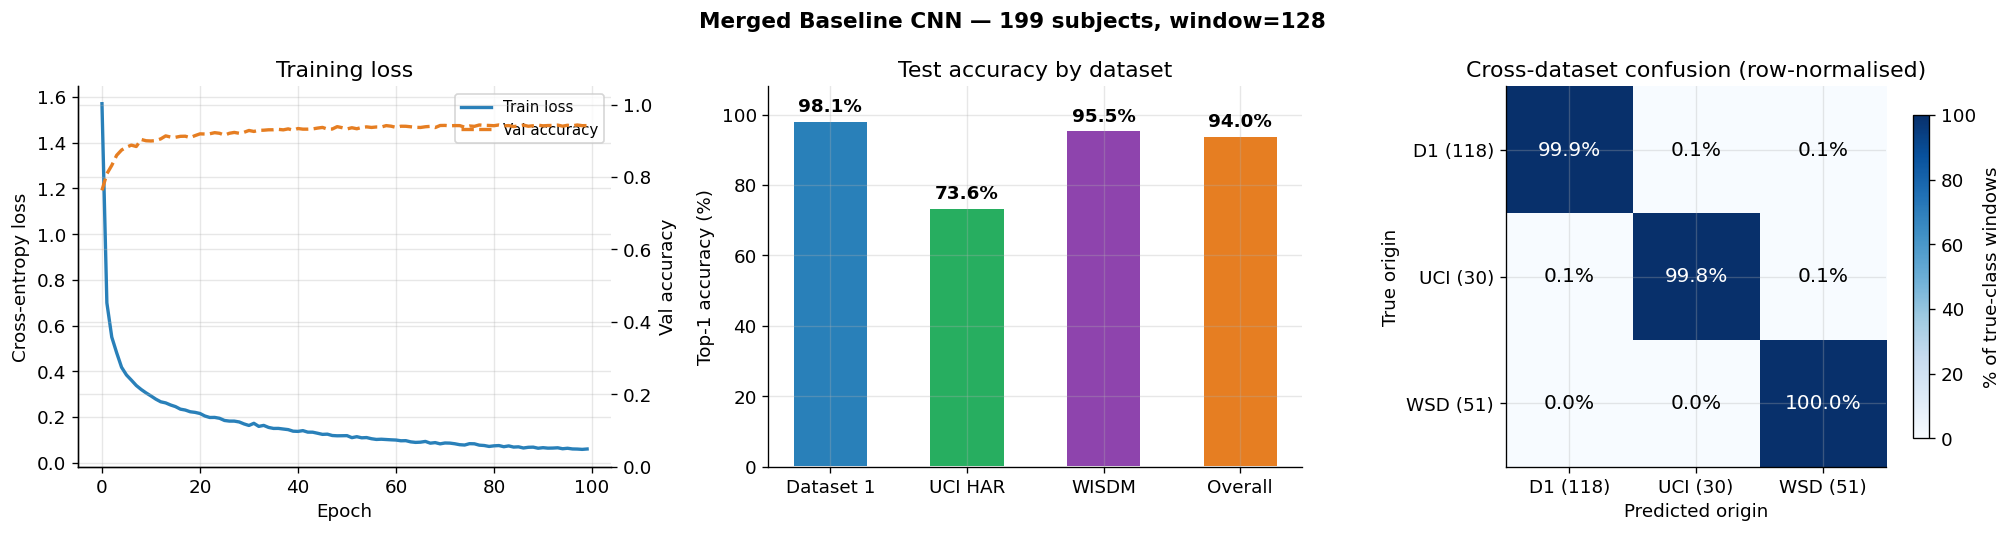

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ── Loss + val accuracy ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(history['loss'], color='#2980B9', lw=2, label='Train loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training loss')

ax2 = ax.twinx()
ax2.plot(history['val_acc'], color='#E67E22', lw=2, ls='--', label='Val accuracy')
ax2.set_ylabel('Val accuracy'); ax2.set_ylim(0, 1.05)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)

# ── Per-dataset accuracy bars ─────────────────────────────────────────────────
ax = axes[1]
bar_names   = ['Dataset 1', 'UCI HAR', 'WISDM', 'Overall']
bar_accs    = [per_ds['Dataset 1'] * 100,
               per_ds['UCI HAR']   * 100,
               per_ds['WISDM']     * 100,
               overall             * 100]
bar_colors  = ['#2980B9', '#27AE60', '#8E44AD', '#E67E22']
bars = ax.bar(bar_names, bar_accs, color=bar_colors, width=0.55,
              edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 108)
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Test accuracy by dataset')
for bar, acc in zip(bars, bar_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── Cross-dataset confusion (3×3) ─────────────────────────────────────────────
ax = axes[2]

def _to_src(labels):
    s = np.empty_like(labels)
    s[labels < UCI_OFFSET]  = 0
    s[(labels >= UCI_OFFSET) & (labels < WSD_OFFSET)] = 1
    s[labels >= WSD_OFFSET] = 2
    return s

cm_src = confusion_matrix(_to_src(true_te), _to_src(pred_te), normalize='true')
tick_labels = ['D1 (118)', 'UCI (30)', 'WSD (51)']
im = ax.imshow(cm_src * 100, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='% of true-class windows', shrink=0.85)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(tick_labels); ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted origin'); ax.set_ylabel('True origin')
ax.set_title('Cross-dataset confusion (row-normalised)')
for i in range(3):
    for j in range(3):
        v = cm_src[i, j] * 100
        ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                fontsize=12, color='white' if v > 60 else 'black')

fig.suptitle(f'Merged Baseline CNN — {N_CLASSES} subjects, window=128',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.2  Per-subject accuracy distribution

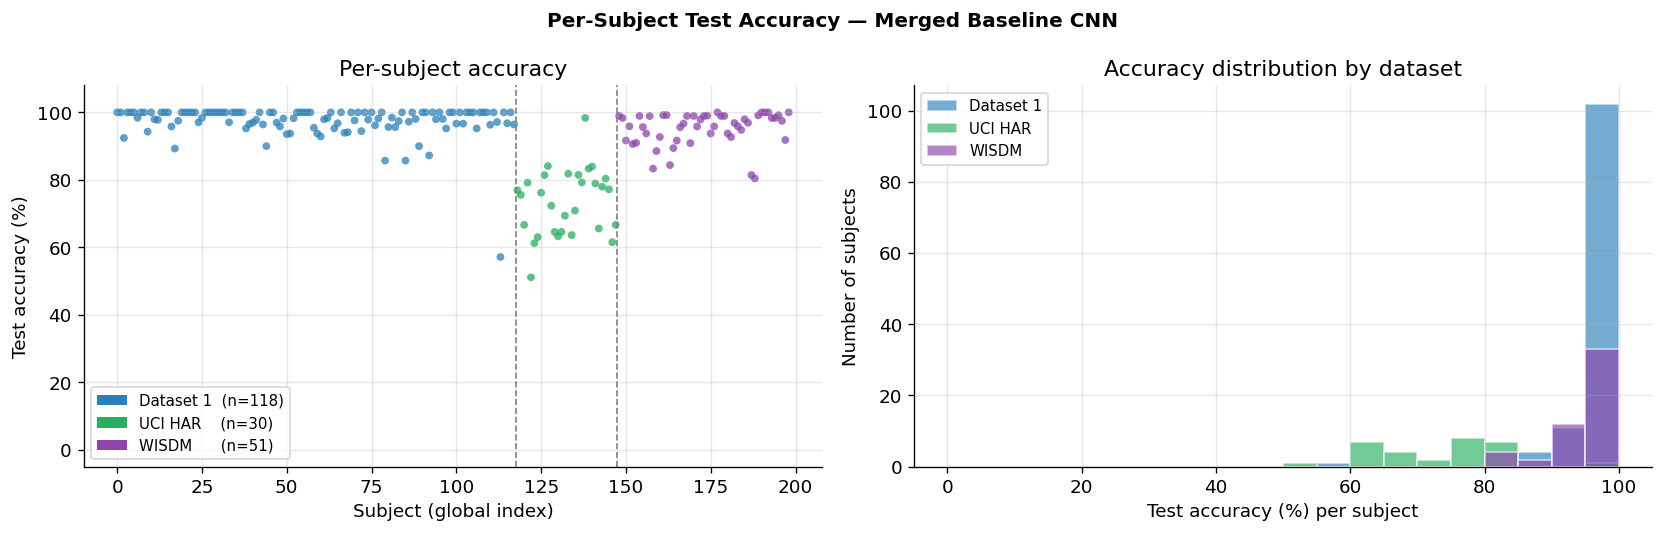

Summary over 199 subjects:
  Mean   : 93.3 %
  Median : 97.6 %
  Std    : 10.3 %
  Min    : 51.1 %  (subject 122)
  Max    : 100.0 %
  >= 80 %: 88 % of subjects


In [60]:
# Compute per-subject accuracy on the test set
subj_accs, subj_ids = [], []
for s in range(N_CLASSES):
    mask = (true_te == s)
    if mask.sum() > 0:
        subj_accs.append((pred_te[mask] == s).mean() * 100)
        subj_ids.append(s)

subj_accs = np.array(subj_accs)
subj_ids  = np.array(subj_ids)

point_colors = np.where(subj_ids < UCI_OFFSET, '#2980B9',
               np.where(subj_ids < WSD_OFFSET, '#27AE60', '#8E44AD'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Scatter
ax = axes[0]
ax.scatter(subj_ids, subj_accs, c=point_colors, s=22, alpha=0.75, edgecolors='none')
ax.axvline(UCI_OFFSET - 0.5, color='gray', lw=1, ls='--')
ax.axvline(WSD_OFFSET - 0.5, color='gray', lw=1, ls='--')
ax.set_xlabel('Subject (global index)'); ax.set_ylabel('Test accuracy (%)')
ax.set_title('Per-subject accuracy'); ax.set_ylim(-5, 108)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2980B9', label=f'Dataset 1  (n={D1_N_CLASSES})'),
    Patch(facecolor='#27AE60', label=f'UCI HAR    (n={UCI_N_CLASSES})'),
    Patch(facecolor='#8E44AD', label=f'WISDM      (n={WSD_N_CLASSES})'),
], fontsize=9)

# Histogram
ax = axes[1]
bins = np.linspace(0, 100, 21)
for tag, name, color in [(0,'Dataset 1','#2980B9'),
                          (1,'UCI HAR',  '#27AE60'),
                          (2,'WISDM',    '#8E44AD')]:
    m = (subj_ids < UCI_OFFSET) if tag == 0 else         ((subj_ids >= UCI_OFFSET) & (subj_ids < WSD_OFFSET)) if tag == 1 else         (subj_ids >= WSD_OFFSET)
    ax.hist(subj_accs[m], bins=bins, alpha=0.65, color=color,
            label=name, edgecolor='white')
ax.set_xlabel('Test accuracy (%) per subject')
ax.set_ylabel('Number of subjects')
ax.set_title('Accuracy distribution by dataset')
ax.legend(fontsize=9)

fig.suptitle('Per-Subject Test Accuracy — Merged Baseline CNN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Summary over {len(subj_accs)} subjects:')
print(f'  Mean   : {subj_accs.mean():.1f} %')
print(f'  Median : {np.median(subj_accs):.1f} %')
print(f'  Std    : {subj_accs.std():.1f} %')
print(f'  Min    : {subj_accs.min():.1f} %  (subject {subj_ids[subj_accs.argmin()]})')
print(f'  Max    : {subj_accs.max():.1f} %')
print(f'  >= 80 %: {(subj_accs >= 80).mean()*100:.0f} % of subjects')
